In [13]:
%pip install numpy pandas scikit-learn tensorflow openpyxl matplotlib

Defaulting to user installation because normal site-packages is not writeable
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.3 MB 5.6 MB/s eta 0:00:02
   ------------- -------------------------- 3.1/9.3 MB 9.7 MB/s eta 0:00:01
   ------------------------- -------------- 6.0/9.3 MB 10.9 MB/s eta 0:00:01
   ----------------------------------- ---- 8.4/9.3 MB 11.1 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 10.2 MB/s eta 0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   -------------------------- ------------- 1.6/2.3 MB 9.3 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 7.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:


[notice] A new release of pip is available: 25.0.1 -> 26.2
[notice] To update, run: C:\Users\ocana\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [14]:
# Todas las importaciones necesarias
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt
import warnings



# Cargar los datos
df = pd.read_excel('Base_Migracion_2009-2026jun.xlsx')

print("¡Importaciones exitosas!")

¡Importaciones exitosas!


In [15]:
# Crear una columna de tipo Datetime uniendo 'Año' y 'Mes cod'
# Usamos el día 1 por defecto para representar el periodo mensual entero
df['Fecha'] = pd.to_datetime({
    'year': df['Año'], 
    'month': df['Mes cod'], 
    'day': 1
})

# Limpieza general: descartar si por alguna razón la fecha o la cantidad de viajeros es nula
df = df.dropna(subset=['Fecha', 'Viajero'])

# Asegurarnos de que toda la base de datos esté ordenada cronológicamente
df = df.sort_values('Fecha').reset_index(drop=True)

print(f"Rango total de los datos: {df['Fecha'].min().date()} hasta {df['Fecha'].max().date()}")

Rango total de los datos: 2009-01-01 hasta 2026-06-01


In [16]:
# Extraemos la secuencia de meses únicos ordenados cronológicamente
meses_unicos = df['Fecha'].drop_duplicates().sort_values().reset_index(drop=True)

# Definimos el punto de corte correspondiente al ~70% del tiempo total disponible
indice_corte = int(len(meses_unicos) * 0.7)
fecha_corte = meses_unicos.iloc[indice_corte]

# Aplicamos la máscara temporal para separar los dataframes
df_train = df[df['Fecha'] < fecha_corte].copy()
df_test  = df[df['Fecha'] >= fecha_corte].copy()

print(f"El punto de corte temporal es: {fecha_corte.date()}\n")
print(f"Set de Entrenamiento: abarca {len(df_train['Fecha'].unique())} meses (hasta {df_train['Fecha'].max().date()})")
print(f"Set de Prueba: abarca {len(df_test['Fecha'].unique())} meses (desde {df_test['Fecha'].min().date()})")

El punto de corte temporal es: 2021-04-01

Set de Entrenamiento: abarca 147 meses (hasta 2021-03-01)
Set de Prueba: abarca 63 meses (desde 2021-04-01)


In [17]:
# ---------------------------------------------------------
# 3. CREACIÓN DE LAS SERIES DE TIEMPO (CORREGIDO)
# ---------------------------------------------------------

# A. Serie Total (Agregada)
serie_total_train = df_train.groupby('Fecha')['Viajero'].sum().resample('MS').sum().to_frame()
serie_total_test = df_test.groupby('Fecha')['Viajero'].sum().resample('MS').sum().to_frame()

# B. Series por Región (Top 3)
top3_regiones = df_train.groupby('Región')['Viajero'].sum().sort_values(ascending=False).head(3).index

series_regiones_train = {}
series_regiones_test = {}

for region in top3_regiones:
    # Train
    series_regiones_train[region] = df_train[df_train['Región']==region].groupby('Fecha')['Viajero'].sum().resample('MS').sum().to_frame()
    # Test
    series_regiones_test[region] = df_test[df_test['Región']==region].groupby('Fecha')['Viajero'].sum().resample('MS').sum().to_frame()

# C. Series por Vía de Ingreso
vias = ["Aéreas", "Terrestre", "Marítima"]
series_vias_train = {}
series_vias_test = {}

for via in vias:
    # Train
    series_vias_train[via] = df_train[df_train['Vía']==via].groupby('Fecha')['Viajero'].sum().resample('MS').sum().to_frame()
    # Test
    series_vias_test[via] = df_test[df_test['Vía']==via].groupby('Fecha')['Viajero'].sum().resample('MS').sum().to_frame()

# D. Series por Tipo de Viajero
tipos = df_train["Tipo de Viajero"].unique()
series_tipos_train = {}
series_tipos_test = {}

for tipo in tipos:
    # Train
    series_tipos_train[tipo] = df_train[df_train['Tipo de Viajero']==tipo].groupby('Fecha')['Viajero'].sum().resample('MS').sum().to_frame()
    # Test
    series_tipos_test[tipo] = df_test[df_test['Tipo de Viajero']==tipo].groupby('Fecha')['Viajero'].sum().resample('MS').sum().to_frame()

# E. Series por Frontera (Top 3)
top3_fronteras = df_train.groupby('Frontera')['Viajero'].sum().sort_values(ascending=False).head(3).index

series_fronteras_train = {}
series_fronteras_test = {}

for frontera in top3_fronteras:
    # Train
    series_fronteras_train[frontera] = df_train[df_train['Frontera']==frontera].groupby('Fecha')['Viajero'].sum().resample('MS').sum().to_frame()
    # Test
    series_fronteras_test[frontera] = df_test[df_test['Frontera']==frontera].groupby('Fecha')['Viajero'].sum().resample('MS').sum().to_frame()

# F. Series por País (Top 3)
col_pais = 'País' if 'País' in df_train.columns else 'Pais'

if col_pais in df_train.columns:
    top3_paises = df_train.groupby(col_pais)['Viajero'].sum().sort_values(ascending=False).head(3).index
    
    series_paises_train = {}
    series_paises_test = {}

    for pais in top3_paises:
        # Train
        series_paises_train[pais] = df_train[df_train[col_pais]==pais].groupby('Fecha')['Viajero'].sum().resample('MS').sum().to_frame()
        # Test
        series_paises_test[pais] = df_test[df_test[col_pais]==pais].groupby('Fecha')['Viajero'].sum().resample('MS').sum().to_frame()

print("¡Series corregidas y listas!")

¡Series corregidas y listas!


In [18]:
# 1.1 Preparación y Normalización de los datos

# 1. Inicializar el escalador
scaler = MinMaxScaler(feature_range=(0, 1))

# 2. Entrenar el escalador solo con los datos de Train y transformar ambos
train_scaled = scaler.fit_transform(serie_total_train[['Viajero']])
test_scaled = scaler.transform(serie_total_test[['Viajero']])

# 3. Función para crear las secuencias (ventanas de tiempo)
def crear_secuencias(datos, pasos_hacia_atras):
    X, y = [], []
    for i in range(len(datos) - pasos_hacia_atras):
        X.append(datos[i:(i + pasos_hacia_atras), 0])
        y.append(datos[i + pasos_hacia_atras, 0])
    return np.array(X), np.array(y)

# Usaremos un año (12 meses) para predecir el mes siguiente
pasos = 12 
X_train, y_train = crear_secuencias(train_scaled, pasos)
X_test, y_test = crear_secuencias(test_scaled, pasos)

# 4. Redimensionar para que TensorFlow lo entienda: [muestras, pasos de tiempo, características]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print(f"Secuencias de Entrenamiento (X_train): {X_train.shape}")
print(f"Secuencias de Prueba (X_test): {X_test.shape}")

Secuencias de Entrenamiento (X_train): (135, 12, 1)
Secuencias de Prueba (X_test): (51, 12, 1)


In [19]:
# 1.2 Construcción del Modelo LSTM con Keras

# Iniciar el modelo secuencial
modelo = Sequential()

# Añadir la capa LSTM con 50 neuronas. 'relu' es una función de activación muy común y efectiva.
modelo.add(LSTM(units=50, activation='relu', input_shape=(X_train.shape[1], 1)))

# Añadir la capa de salida (1 neurona porque solo predecimos un valor: el siguiente mes)
modelo.add(Dense(units=1))

# Compilar el modelo: usamos 'adam' como optimizador y MSE para medir el error
modelo.compile(optimizer='adam', loss='mean_squared_error')

# Mostrar un resumen de la arquitectura construida
modelo.summary()

C:\Users\ocana\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# 1.3 Entrenamiento del Modelo

print("Iniciando el entrenamiento de la red LSTM...")

# Entrenamos por 50 épocas (pasadas completas a los datos)
historial = modelo.fit(
    X_train, 
    y_train, 
    epochs=50, 
    batch_size=8, 
    validation_data=(X_test, y_test), 
    verbose=1 # Muestra la barra de progreso
)

print("\n¡Entrenamiento completado con éxito!")

Iniciando el entrenamiento de la red LSTM...
Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.1510 - val_loss: 0.0745
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0258 - val_loss: 0.0256
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0241 - val_loss: 0.0289
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0216 - val_loss: 0.0226
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0211 - val_loss: 0.0240
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0208 - val_loss: 0.0235
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0206 - val_loss: 0.0243
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0198 - val_loss: 0.0218
Epoch 9/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0196 - val_loss: 0.0223
Epoch 10/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0191 - val_loss: 0.0212
Epoch 11/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0187 - val_loss: 0.0216
Epoch 12/50
17/17 ━━━━

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step

--- MÉTRICAS DE ERROR ---
Error Cuadrático Medio (MSE): 5,611,603,854.84
Raíz del Error Cuadrático Medio (RMSE): 74,910.64 viajeros de diferencia promedio


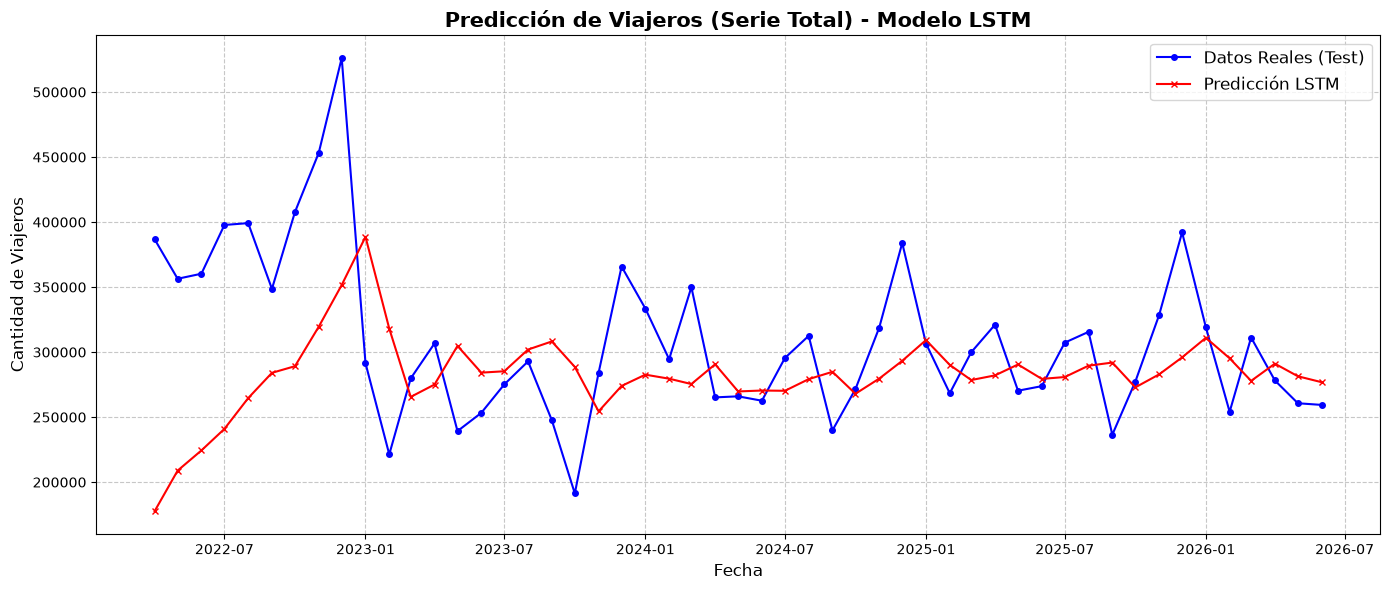

In [21]:
# 1.4 Predicción y Evaluación Gráfica

# 1. Hacer predicciones usando los datos de prueba
predicciones_escaladas = modelo.predict(X_test)

# 2. Revertir la normalización para volver a la escala original de viajeros
predicciones = scaler.inverse_transform(predicciones_escaladas)
y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1))

# 3. Calcular métricas de error
mse = mean_squared_error(y_test_real, predicciones)
rmse = np.sqrt(mse)
print(f"\n--- MÉTRICAS DE ERROR ---")
print(f"Error Cuadrático Medio (MSE): {mse:,.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:,.2f} viajeros de diferencia promedio")

# 4. Graficar los resultados
plt.figure(figsize=(14, 6))

# Las fechas correspondientes a las predicciones (saltando los primeros 12 meses usados como pasos)
fechas_prediccion = serie_total_test.index[pasos:]

# Gráfico de líneas
plt.plot(fechas_prediccion, y_test_real, label='Datos Reales (Test)', color='blue', marker='o', markersize=4)
plt.plot(fechas_prediccion, predicciones, label='Predicción LSTM', color='red', marker='x', markersize=4)

plt.title('Predicción de Viajeros (Serie Total) - Modelo LSTM', fontsize=15, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Cantidad de Viajeros', fontsize=12)
plt.legend(loc='best', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()